# ARK Invest: Skill or Luck?

In [1]:
# ── Librerie base ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualizzazione ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Econometria / Statistica ───────────────────────────────────────────────────
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.compat import lzip
from statsmodels.regression.rolling import RollingOLS
from statsmodels.datasets import longley
from statsmodels.iolib.summary2 import summary_col
from statsmodels.tsa.stattools import adfuller

from scipy import stats
from scipy.stats import norm, linregress

# ── Machine Learning / PCA / Clustering ───────────────────────────────────────
from sklearn.decomposition import PCA
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

# ── Ottimizzazione portafoglio ─────────────────────────────────────────────────
from pypfopt import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns

# ── Dati finanziari ────────────────────────────────────────────────────────────
import yfinance as yf
import fmfinance as fm
import financedatabase as fd
import quantstats as qs

# ── Calcolo parallelo ──────────────────────────────────────────────────────────
from joblib import Parallel, delayed

# ── Interfaccia R ──────────────────────────────────────────────────────────────
import rpy2.robjects as ro
from rpy2.robjects.packages import importr

# ── Trading algoritmico (Alpaca) ───────────────────────────────────────────────
from alpaca.trading.client import TradingClient
from alpaca.trading.requests import MarketOrderRequest, LimitOrderRequest, ClosePositionRequest
from alpaca.trading.enums import OrderSide, TimeInForce
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockLatestTradeRequest, StockLatestQuoteRequest

# ── Web scraping ───────────────────────────────────────────────────────────────
import requests
from bs4 import BeautifulSoup
from io import StringIO

# ── UI interattiva ─────────────────────────────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display

# ── Utility ────────────────────────────────────────────────────────────────────
from datetime import datetime
from pandas.plotting import register_matplotlib_converters
import random
import time
import os
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Data Setup

In [2]:
start = '2019-01-01'
end = '2024-12-31'

ff4f = fm.ff('4_factors', start, end)[0]

tickers = ['ARKK', 'ARKW', 'ARKG', 'ARKF', 'ARKQ', 'SPY']
prices = yf.download(tickers, start=start, end=end,
                     auto_adjust=False, multi_level_index=False, interval='1mo')['Adj Close']

display(ff4f)
display(prices)

[*********************100%***********************]  6 of 6 completed


,Mkt-RF,SMB,HML,Mom,RF
Date,,,,,
2019-01-01,8.37,2.76,-0.39,-8.62,0.21
2019-02-01,3.42,2.05,-2.66,0.50,0.18
2019-03-01,1.10,-3.03,-4.14,2.24,0.19
2019-04-01,3.97,-1.74,2.13,-2.91,0.21
2019-05-01,-6.92,-1.26,-2.45,7.55,0.21
...,...,...,...,...,...
2024-08-01,1.60,-3.50,-1.10,4.86,0.48
2024-09-01,1.72,-0.12,-2.77,-0.56,0.40
2024-10-01,-1.00,-0.96,0.89,2.94,0.39


Ticker,ARKF,ARKG,ARKK,ARKQ,ARKW,SPY
Date,,,,,,
2019-01-01,NaN,27.011173,41.523792,32.629162,46.841202,242.096024
2019-02-01,20.852495,29.461514,44.909359,34.610847,49.130291,249.943680
2019-03-01,21.196594,31.471558,45.073334,33.394367,49.007324,253.351898
2019-04-01,22.278053,31.308840,45.545959,33.959446,50.482929,264.863464
2019-05-01,20.685360,27.872620,39.286041,28.783514,45.015606,247.972809
...,...,...,...,...,...,...
2024-08-01,28.275276,26.389999,44.820000,56.085991,77.984314,552.062927
2024-09-01,29.793949,25.600000,47.529999,60.763977,83.833870,561.935181
2024-10-01,30.843033,23.139999,45.889999,60.823826,85.636009,558.628967


In [3]:
returns    = prices.pct_change()*100
returns.dropna(inplace=True)
returns

Ticker,ARKF,ARKG,ARKK,ARKQ,ARKW,SPY
Date,,,,,,
2019-03-01,1.650158,6.822610,0.365124,-3.514737,-0.250287,1.363595
2019-04-01,5.102042,-0.517031,1.048571,1.692138,3.010989,4.543706
2019-05-01,-7.149158,-10.975240,-13.744179,-15.241509,-10.830044,-6.377118
2019-06-01,7.652083,18.372261,17.800148,15.064750,9.287661,6.440961
2019-07-01,0.958059,0.319122,1.000415,-2.073456,0.903667,2.005657
...,...,...,...,...,...,...
2024-08-01,3.967675,-2.077927,-1.559409,-0.530686,1.799718,2.336555
2024-09-01,5.371028,-2.993554,6.046406,8.340739,7.500939,1.788248
2024-10-01,3.521130,-9.609379,-3.450451,0.098494,2.149655,-0.588362


In [4]:
rf = ff4f['RF']
er = returns.subtract(rf, axis=0).dropna()

display(er.round(2))

Ticker,ARKF,ARKG,ARKK,ARKQ,ARKW,SPY
Date,,,,,,
2019-03-01,1.46,6.63,0.18,-3.70,-0.44,1.17
2019-04-01,4.89,-0.73,0.84,1.48,2.80,4.33
2019-05-01,-7.36,-11.19,-13.95,-15.45,-11.04,-6.59
2019-06-01,7.47,18.19,17.62,14.88,9.11,6.26
2019-07-01,0.77,0.13,0.81,-2.26,0.71,1.82
...,...,...,...,...,...,...
2024-08-01,3.49,-2.56,-2.04,-1.01,1.32,1.86
2024-09-01,4.97,-3.39,5.65,7.94,7.10,1.39
2024-10-01,3.13,-10.00,-3.84,-0.29,1.76,-0.98


## Return Analysis

In [ ]:
# ── Statistiche descrittive comparative (Fase 1) ──────────────────────────────
# Tutti gli ETF + SPY, dati mensili → periods_per_year=12
# Pattern ripreso da Es01_Return_Analysis.ipynb

etf_tickers = ['ARKF', 'ARKG', 'ARKK', 'ARKQ', 'ARKW', 'SPY']

# Rendimenti in eccesso in formato decimale per quantstats
er_qs = er[etf_tickers] / 100

# Loop su ogni strumento per raccogliere le metriche
statistiche = {}

for ticker in etf_tickers:
    rets = er_qs[ticker].dropna()
    statistiche[ticker] = {
        'Media mensile (%)':    round(er[ticker].mean(), 3),
        'Std. Dev. mensile (%)': round(er[ticker].std(), 3),
        'Skewness':             round(er[ticker].skew(), 3),
        'Curtosi (excess)':     round(er[ticker].kurt(), 3),
        'Min (%)':              round(er[ticker].min(), 3),
        'Max (%)':              round(er[ticker].max(), 3),
        'CAGR (%)': round(qs.stats.cagr(rets, periods=12) * 100, 3),
        'Volatilità ann. (%)':  round(qs.stats.volatility(rets, periods=12) * 100, 3),
        'Sharpe (ann.)':        round(qs.stats.sharpe(rets, periods=12), 3),
        'Sortino (ann.)':       round(qs.stats.sortino(rets, periods=12), 3),
        'Max Drawdown (%)':     round(qs.stats.max_drawdown(rets) * 100, 3),
        'VaR 5% (%)':           round(qs.stats.value_at_risk(rets, sigma=0.05) * 100, 3),
        'CVaR 5% (%)':          round(qs.stats.cvar(rets, confidence=0.95) * 100, 3),
    }

# Costruzione DataFrame trasposto (metriche per riga, ETF per colonna)
df_stats = pd.DataFrame(statistiche)
display(df_stats)

,ARKF,ARKG,ARKK,ARKQ,ARKW,SPY
Media mensile (%),1.255,0.152,0.880,1.339,1.570,1.135
Std. Dev. mensile (%),11.314,11.705,12.379,8.931,11.617,5.104
Skewness,0.199,0.292,0.372,0.364,0.218,-0.404
Curtosi (excess),0.231,-0.401,-0.177,-0.107,-0.156,0.262
Min (%),-27.022,-25.974,-28.903,-16.302,-26.542,-13.119
Max (%),29.737,30.083,31.002,25.477,28.807,13.361
CAGR (%),7.844,-6.023,1.709,12.088,11.570,12.756
Volatilità ann. (%),39.194,40.548,42.883,30.937,40.244,17.682
Sharpe (ann.),0.384,0.045,0.246,0.519,0.468,0.770
Sortino (ann.),0.617,0.069,0.404,0.901,0.777,1.205


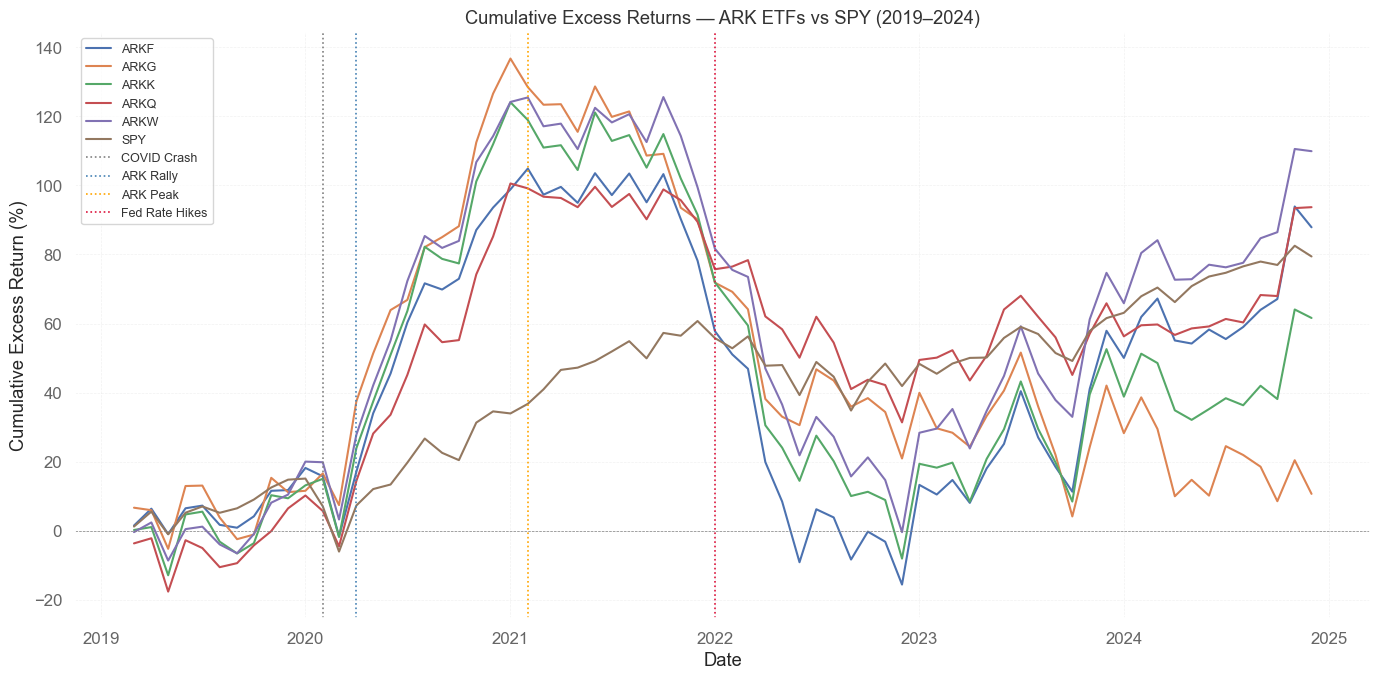

In [17]:
# Rendimenti cumulati
cum_er = er[etf_tickers].cumsum()

fig, ax = plt.subplots(figsize=(14, 7))

for ticker in etf_tickers:
    ax.plot(cum_er.index, cum_er[ticker], label=ticker, linewidth=1.5)

# Linee verticali
ax.axvline(pd.Timestamp('2020-02-01'), color='gray',     linestyle=':', linewidth=1.2, label='COVID Crash')
ax.axvline(pd.Timestamp('2020-04-01'), color='steelblue',linestyle=':', linewidth=1.2, label='ARK Rally')
ax.axvline(pd.Timestamp('2021-02-01'), color='orange',   linestyle=':', linewidth=1.2, label='ARK Peak')
ax.axvline(pd.Timestamp('2022-01-01'), color='crimson',  linestyle=':', linewidth=1.2, label='Fed Rate Hikes')

ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_title('Cumulative Excess Returns — ARK ETFs vs SPY (2019–2024)')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Excess Return (%)')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [15]:
display(er.round(2))

Ticker,ARKF,ARKG,ARKK,ARKQ,ARKW,SPY
Date,,,,,,
2019-03-01,1.46,6.63,0.18,-3.70,-0.44,1.17
2019-04-01,4.89,-0.73,0.84,1.48,2.80,4.33
2019-05-01,-7.36,-11.19,-13.95,-15.45,-11.04,-6.59
2019-06-01,7.47,18.19,17.62,14.88,9.11,6.26
2019-07-01,0.77,0.13,0.81,-2.26,0.71,1.82
...,...,...,...,...,...,...
2024-08-01,3.49,-2.56,-2.04,-1.01,1.32,1.86
2024-09-01,4.97,-3.39,5.65,7.94,7.10,1.39
2024-10-01,3.13,-10.00,-3.84,-0.29,1.76,-0.98


In [ ]:
# Matrice di correlazione
er[etf_tickers].corr().style.background_gradient(cmap='coolwarm', vmin=0, vmax=1)

Ticker,ARKF,ARKG,ARKK,ARKQ,ARKW,SPY
Ticker,,,,,,
ARKF,1.000000,0.816518,0.937567,0.862174,0.971968,0.744096
ARKG,0.816518,1.000000,0.912701,0.807723,0.834143,0.657313
ARKK,0.937567,0.912701,1.000000,0.914741,0.967251,0.716254
ARKQ,0.862174,0.807723,0.914741,1.000000,0.901813,0.748568
ARKW,0.971968,0.834143,0.967251,0.901813,1.000000,0.731845
SPY,0.744096,0.657313,0.716254,0.748568,0.731845,1.000000
